In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from IPython.display import IFrame
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc
%matplotlib inline

In [11]:
dataset = pd.read_csv("west-midlands-street.csv")

# Let's visualise the dataframe.

In [12]:
dataset.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-09,West Midlands Police,West Midlands Police,-1.850772,52.588709,On or near Seymour Gardens,E01009417,Birmingham 001A,Anti-social behaviour,NaN,NaN
1,7a8b7c7f0b8e6f113788e25ec5edf45268fd614ae70307...,2024-09,West Midlands Police,West Midlands Police,-1.849177,52.593202,On or near Russell Bank Road,E01009417,Birmingham 001A,Vehicle crime,Unable to prosecute suspect,NaN
2,620cd472328f788c78bb36d59e58a65fe3df5631692be7...,2024-09,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Vehicle crime,Under investigation,NaN
3,482aa09a8759507ae8fc3ce5e2ae954bec63e0b7695f42...,2024-09,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified,NaN
4,242dabdcb663b6fc50b7a7cdb5a32c12c6b409fe7d8f1e...,2024-09,West Midlands Police,West Midlands Police,-1.847123,52.593864,On or near Bramble Way,E01009417,Birmingham 001A,Violence and sexual offences,Action to be taken by another organisation,NaN


In [13]:
print(dataset.shape)

(28635, 12)


In [14]:
name_number = "Javohir_2427229.csv"
dataset.to_csv(name_number, index=False)

# Now read the saved csv to a Pandas dataframe using the following code

In [15]:
data = pd.read_csv(name_number)

In [16]:
data['Crime type'].value_counts()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-09,West Midlands Police,West Midlands Police,-1.850772,52.588709,On or near Seymour Gardens,E01009417,Birmingham 001A,Anti-social behaviour,NaN,NaN
1,7a8b7c7f0b8e6f113788e25ec5edf45268fd614ae70307...,2024-09,West Midlands Police,West Midlands Police,-1.849177,52.593202,On or near Russell Bank Road,E01009417,Birmingham 001A,Vehicle crime,Unable to prosecute suspect,NaN


In [17]:
data.head(2)

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-09,West Midlands Police,West Midlands Police,-1.850772,52.588709,On or near Seymour Gardens,E01009417,Birmingham 001A,Anti-social behaviour,NaN,NaN
1,7a8b7c7f0b8e6f113788e25ec5edf45268fd614ae70307...,2024-09,West Midlands Police,West Midlands Police,-1.849177,52.593202,On or near Russell Bank Road,E01009417,Birmingham 001A,Vehicle crime,Unable to prosecute suspect,NaN


In [18]:
data['town'] = data['LSOA name'].str.split(' ').str[0]

# After having a new column 'town' added to data, let's visualise the dataframe.

In [19]:
data.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,town
0,NaN,2024-09,West Midlands Police,West Midlands Police,-1.850772,52.588709,On or near Seymour Gardens,E01009417,Birmingham 001A,Anti-social behaviour,NaN,NaN,Birmingham
1,7a8b7c7f0b8e6f113788e25ec5edf45268fd614ae70307...,2024-09,West Midlands Police,West Midlands Police,-1.849177,52.593202,On or near Russell Bank Road,E01009417,Birmingham 001A,Vehicle crime,Unable to prosecute suspect,NaN,Birmingham
2,620cd472328f788c78bb36d59e58a65fe3df5631692be7...,2024-09,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Vehicle crime,Under investigation,NaN,Birmingham
3,482aa09a8759507ae8fc3ce5e2ae954bec63e0b7695f42...,2024-09,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified,NaN,Birmingham
4,242dabdcb663b6fc50b7a7cdb5a32c12c6b409fe7d8f1e...,2024-09,West Midlands Police,West Midlands Police,-1.847123,52.593864,On or near Bramble Way,E01009417,Birmingham 001A,Violence and sexual offences,Action to be taken by another organisation,NaN,Birmingham


In [20]:
towns = ['Wolverhampton']
filtered_data = data[data.town.str.contains('|'.join(towns), na=False)]
filtered_data.head()


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,town
25999,821ae8bcc828f27cb4ffea8953e503865e57aba46aac7f...,2024-09,West Midlands Police,West Midlands Police,-2.126190,52.620038,On or near Three Tuns Lane,E01010434,Wolverhampton 001A,Burglary,Under investigation,NaN,Wolverhampton
26000,07f95e8dd21b0781f51e84210c70db90639d5fae9c352e...,2024-09,West Midlands Police,West Midlands Police,-2.127385,52.619632,On or near Crathorne Avenue,E01010434,Wolverhampton 001A,Other theft,Investigation complete; no suspect identified,NaN,Wolverhampton
26001,ab48cb4eeee2c5b1b54a1318a36782a4ea4e8e37306305...,2024-09,West Midlands Police,West Midlands Police,-2.127385,52.619632,On or near Crathorne Avenue,E01010434,Wolverhampton 001A,Other theft,Under investigation,NaN,Wolverhampton
26002,fec89a59d9b041df7526e6663120b3098fd3168a5cdab7...,2024-09,West Midlands Police,West Midlands Police,-2.129354,52.620825,On or near Three Tuns Parade,E01010434,Wolverhampton 001A,Shoplifting,Investigation complete; no suspect identified,NaN,Wolverhampton
26003,0f70ff4b781f37dc92bb5f7d5e126a92e39ff35b2fa965...,2024-09,West Midlands Police,West Midlands Police,-2.129354,52.620825,On or near Three Tuns Parade,E01010434,Wolverhampton 001A,Shoplifting,Investigation complete; no suspect identified,NaN,Wolverhampton


# Q2. Display crime types in Wolverhampton.

In [22]:
crime_types = filtered_data['Crime type'].head(5)
crime_types

,Crime type
25999,Burglary
26000,Other theft
26001,Other theft
26002,Shoplifting
26003,Shoplifting


In [23]:
filtered_data['LSOA code'].value_counts().nlargest(10)

,count
LSOA code,
E01034313,151
E01034312,113
E01010564,103
E01010414,72
E01010530,69
E01010473,52
E01010476,49
E01010450,43
E01010410,43


# Q3. Provide a prime landmark of alteast 2 LSOA codes. If there is no recognisable prime landmark, provide name(s) of the nearby streets/roads surrounding that area.

In [26]:
filtered_data['LSOA code'].value_counts().nlargest(2)

,count
LSOA code,
E01034313,151
E01034312,113


In [27]:
filtered_important_data = filtered_data[['LSOA code','Crime type']]
filtered_important_data.head(10)

,LSOA code,Crime type
25999,E01010434,Burglary
26000,E01010434,Other theft
26001,E01010434,Other theft
26002,E01010434,Shoplifting
26003,E01010434,Shoplifting
26004,E01010434,Vehicle crime
26005,E01010434,Violence and sexual offences
26006,E01010434,Violence and sexual offences
26007,E01010434,Violence and sexual offences
26008,E01010434,Violence and sexual offences


In [28]:
filtered_important_data['Crime type'].value_counts()

,count
Crime type,
Violence and sexual offences,1026
Shoplifting,304
Vehicle crime,213
Anti-social behaviour,203
Criminal damage and arson,177
Other theft,165
Public order,157
Burglary,120
Other crime,66


# We will consider all the crimes for this analysis and we are interested in transforming each 'crime type' as a single column. And, filling out the counts of it. Function get_dummies() can be used to perform this

In [29]:
filtered_important_data = filtered_data[['LSOA code','Crime type']]
filtered_important_data = pd.get_dummies(filtered_important_data, columns=['Crime type'])
clustering_data = filtered_important_data.groupby(['LSOA code']).agg({
                'Crime type_Anti-social behaviour':'sum',
                'Crime type_Bicycle theft':'sum',
                'Crime type_Burglary':'sum',
                'Crime type_Criminal damage and arson':'sum',
                'Crime type_Drugs':'sum',
                'Crime type_Other crime':'sum',
                'Crime type_Other theft':'sum',
                'Crime type_Possession of weapons':'sum',
                'Crime type_Public order':'sum',
                'Crime type_Robbery':'sum',
                'Crime type_Shoplifting':'sum',
                'Crime type_Theft from the person':'sum',
                'Crime type_Vehicle crime':'sum',
                'Crime type_Violence and sexual offences':'sum'}).reset_index()



In [30]:
clustering_data[:5]

,LSOA code,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
0,E01010410,2,0,3,2,0,0,6,1,1,0,18,0,2,8
1,E01010411,2,0,2,0,0,0,2,0,1,0,0,0,4,2
2,E01010412,1,0,3,0,0,1,1,0,0,0,5,0,1,10
3,E01010413,1,0,3,1,0,0,1,0,4,0,0,0,0,3
4,E01010414,1,2,6,2,1,1,2,4,6,0,11,2,6,28


In [31]:
clustering_data_original = clustering_data.copy()
clustering_data_original.head()

,LSOA code,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
0,E01010410,2,0,3,2,0,0,6,1,1,0,18,0,2,8
1,E01010411,2,0,2,0,0,0,2,0,1,0,0,0,4,2
2,E01010412,1,0,3,0,0,1,1,0,0,0,5,0,1,10
3,E01010413,1,0,3,1,0,0,1,0,4,0,0,0,0,3
4,E01010414,1,2,6,2,1,1,2,4,6,0,11,2,6,28


In [32]:
clustering_data.drop(['LSOA code'], axis = 1, inplace = True, errors = 'ignore')
clustering_data.head()

,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
0,2,0,3,2,0,0,6,1,1,0,18,0,2,8
1,2,0,2,0,0,0,2,0,1,0,0,0,4,2
2,1,0,3,0,0,1,1,0,0,0,5,0,1,10
3,1,0,3,1,0,0,1,0,4,0,0,0,0,3
4,1,2,6,2,1,1,2,4,6,0,11,2,6,28


In [33]:
data_scaled = normalize(clustering_data)
data_scaled = pd.DataFrame(data_scaled, columns=clustering_data.columns)
data_scaled.head()

,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
0,0.094597,0.00000,0.141895,0.094597,0.00000,0.000000,0.283790,0.047298,0.047298,0.0,0.851371,0.00000,0.094597,0.378387
1,0.348155,0.00000,0.348155,0.000000,0.00000,0.000000,0.348155,0.000000,0.174078,0.0,0.000000,0.00000,0.696311,0.348155
2,0.085126,0.00000,0.255377,0.000000,0.00000,0.085126,0.085126,0.000000,0.000000,0.0,0.425628,0.00000,0.085126,0.851257
3,0.164399,0.00000,0.493197,0.164399,0.00000,0.000000,0.164399,0.000000,0.657596,0.0,0.000000,0.00000,0.000000,0.493197
4,0.030890,0.06178,0.185341,0.061780,0.03089,0.030890,0.061780,0.123560,0.185341,0.0,0.339791,0.06178,0.185341,0.864923


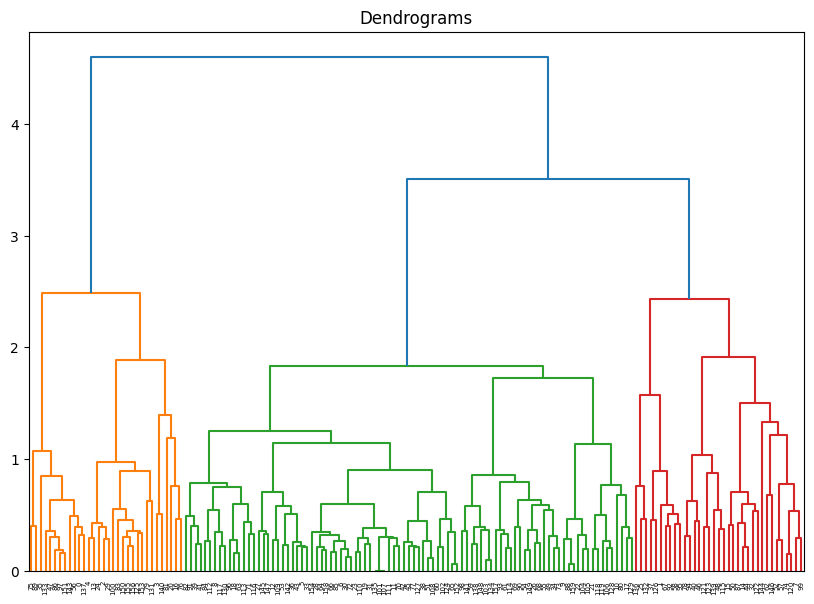

In [34]:
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

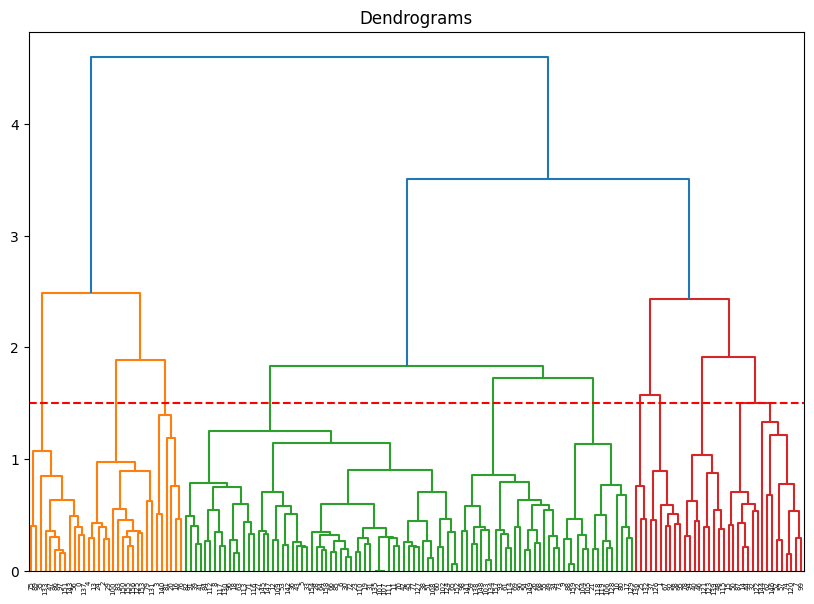

In [35]:
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=1.5, color='r', linestyle='--')

# 4. Discuss what happens when you decide to cut the dendogram in different level

The level at which we cut the dendrogram in hierarchical clustering affects the number and type of clusters that we obtain. The higher we cut, the fewer larger, more diverse clusters that capture broader patterns we get, while with lower cuts we get more smaller and more similar clusters-the finer details.

# Let's perform the clustering using n_clusters as 3.

In [37]:
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_ids = cluster.fit_predict(data_scaled)

# Let's visualise the dataset with clusters

In [38]:
clustering_data['cluster'] = cluster_ids
clustering_data.head()

,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences,cluster
0,2,0,3,2,0,0,6,1,1,0,18,0,2,8,0
1,2,0,2,0,0,0,2,0,1,0,0,0,4,2,1
2,1,0,3,0,0,1,1,0,0,0,5,0,1,10,0
3,1,0,3,1,0,0,1,0,4,0,0,0,0,3,0
4,1,2,6,2,1,1,2,4,6,0,11,2,6,28,0


In [39]:
hiarchical_cluster = pd.DataFrame(round(clustering_data.groupby('cluster').mean(),1))
hiarchical_cluster

,Crime type_Anti-social behaviour,Crime type_Bicycle theft,Crime type_Burglary,Crime type_Criminal damage and arson,Crime type_Drugs,Crime type_Other crime,Crime type_Other theft,Crime type_Possession of weapons,Crime type_Public order,Crime type_Robbery,Crime type_Shoplifting,Crime type_Theft from the person,Crime type_Vehicle crime,Crime type_Violence and sexual offences
cluster,,,,,,,,,,,,,,
0,1.4,0.2,1.4,1.0,0.4,0.4,1.7,0.6,1.7,0.3,7.9,0.2,1.3,6.1
1,1.1,0.2,1.1,1.3,0.3,0.4,0.6,0.3,0.4,0.1,0.3,0.2,2.1,3.1
2,1.3,0.1,0.4,1.1,0.4,0.4,1.0,0.3,1.0,0.2,0.5,0.1,1.0,7.8


# Q5. Discuss the clustering results based on your dataset

Answer5:

Cluster1: Areas with high overall crime rates, likely busy city centers or commercial hubs.
Cluster 2: Areas dominated by specific crimes, such as anti-social behavior or property crime, often residential neighborhoods with targeted issues
Cluster 3: Areas with low crime rates, possibly safer or less populated regions.

# Using the following code, we are merging cluster ID to each LSOA code

In [40]:
clustering_data_original['cluster'] = cluster_ids
clusters = clustering_data_original[['LSOA code', 'cluster']]

In [42]:
clusters.head()

,LSOA code,cluster
0,E01010410,0
1,E01010411,1
2,E01010412,0
3,E01010413,0
4,E01010414,0


#  Let's assign each crime to a cluster based on the LSOA code

In [43]:
clustered_full = pd.merge(filtered_data, clusters, on='LSOA code')
clustered_full.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,town,cluster
0,821ae8bcc828f27cb4ffea8953e503865e57aba46aac7f...,2024-09,West Midlands Police,West Midlands Police,-2.126190,52.620038,On or near Three Tuns Lane,E01010434,Wolverhampton 001A,Burglary,Under investigation,NaN,Wolverhampton,0
1,07f95e8dd21b0781f51e84210c70db90639d5fae9c352e...,2024-09,West Midlands Police,West Midlands Police,-2.127385,52.619632,On or near Crathorne Avenue,E01010434,Wolverhampton 001A,Other theft,Investigation complete; no suspect identified,NaN,Wolverhampton,0
2,ab48cb4eeee2c5b1b54a1318a36782a4ea4e8e37306305...,2024-09,West Midlands Police,West Midlands Police,-2.127385,52.619632,On or near Crathorne Avenue,E01010434,Wolverhampton 001A,Other theft,Under investigation,NaN,Wolverhampton,0
3,fec89a59d9b041df7526e6663120b3098fd3168a5cdab7...,2024-09,West Midlands Police,West Midlands Police,-2.129354,52.620825,On or near Three Tuns Parade,E01010434,Wolverhampton 001A,Shoplifting,Investigation complete; no suspect identified,NaN,Wolverhampton,0
4,0f70ff4b781f37dc92bb5f7d5e126a92e39ff35b2fa965...,2024-09,West Midlands Police,West Midlands Police,-2.129354,52.620825,On or near Three Tuns Parade,E01010434,Wolverhampton 001A,Shoplifting,Investigation complete; no suspect identified,NaN,Wolverhampton,0


# Then give a color to all the cluster IDs. Since we are using it for visualisations, 'darkred' is used for the cluster with high crime and 'green' for the cluster with low crimes

In [44]:
def get_color(cluster_id):
      if cluster_id == 2:
        return 'darkred'
      if cluster_id == 1:
        return 'green'
      if cluster_id == 0:
        return 'yellow'

# Using the following code, we are creating a map with clusters

In [49]:
import folium
import os
#create a map

center_lat = clustered_full["Latitude"].mean()
center_lon = clustered_full["Longitude"].mean()

this_map = folium.Map(location=[center_lat, center_lon])


clustered_full['color'] = clustered_full['cluster'].apply(get_color)

def plot_dot(point):
            '''input: series that contains a numeric named
            latitude and a numeric named longitude
            this function creates a CircleMarker and adds it to your this_map'''
            folium.CircleMarker(location=[point.Latitude, point.Longitude],
                                radius=2,
                                color=point.color,
                                weight=1).add_to(this_map)
clustered_full.apply(plot_dot, axis = 1)

this_map.fit_bounds(this_map.get_bounds())

this_map.save(os.path.join('Crime_map.html'))

# Answer the following questions

Discuss the results (your understanding) of the clustering algorithm on clustering crime dataset used in this
work (Max 500 words).
Change the number of clusters to a different value and perform the clustering algorithm and draw the graph
again. Discuss your results briefly.
Consider a different towns (example : dudley) and perform the clustering again. You should choose the
number of clusters from the dendrogram accordingly. Discuss your results briefly

### **Crime Clustering in Wolverhampton and Dudley**

---

### **Introduction**

This report presents the findings of a crime clustering analysis conducted on data from Wolverhampton and Dudley, two towns in the West Midlands region of England. The study used hierarchical clustering to identify spatial patterns of crime, aiming to better understand the unique characteristics of different areas.

---

### **Methodology**

The analysis utilized a crime dataset containing:
- **Crime type**  
- **Coordinates (latitude and longitude)**  
- **LSOA (Lower Layer Super Output Area) codes**  

Key steps in the methodology:
1. **Data Preprocessing**: Crime data was filtered to focus separately on Wolverhampton and Dudley.
2. **Clustering Algorithm**: Agglomerative Hierarchical Clustering with Ward linkage was employed to group LSOAs based on crime type occurrences.
3. **Cluster Selection**:
   - Wolverhampton: Initially set to 3 clusters.
   - Dudley: Optimal cluster count determined by analyzing a dendrogram.

---

### **Results**

#### **Wolverhampton (3 Clusters)**
The clustering divided Wolverhampton into three distinct groups:

1. **Cluster 0 (Yellow)**:
   - Represents areas with **medium crime levels**.
   - Likely includes a mix of residential and commercial zones with a balanced distribution of crime types.

2. **Cluster 1 (Green)**:
   - Depicts **low-crime areas**.
   - Likely residential neighborhoods with low population density or effective crime prevention measures.

3. **Cluster 2 (Dark Red)**:
   - Highlights **high-crime areas**.
   - Likely busy city centers or commercial zones where dense populations and economic activities create opportunities for crime.

#### **Wolverhampton (4 Clusters)**
Expanding the clustering to 4 groups provided greater granularity, distinguishing areas further by crime types (e.g., property vs. violent crimes). This level of detail could better target interventions for specific crime categories.

#### **Dudley**
While the exact number of clusters for Dudley is not specified, the dendrogram's optimal cluster count likely revealed patterns unique to Dudley. These patterns might differ from Wolverhampton, reflecting Dudley's distinct socio-economic and spatial characteristics.

---

### **Discussion and Insights**

The clustering results provide valuable insights into the spatial distribution of crime in Wolverhampton and Dudley. Key takeaways:
- **High-risk clusters** pinpoint areas requiring targeted law enforcement interventions.
- **Low-crime clusters** offer models of effective prevention strategies that can be replicated elsewhere.
- Differences between Wolverhampton and Dudley highlight the need for town-specific approaches to crime reduction.

---

### **Recommendations**

1. **Strategic Resource Deployment**:
   - Law enforcement agencies should prioritize high-risk clusters for resource allocation and targeted crime prevention strategies.

2. **Community Engagement**:
   - Local leaders and residents can collaborate to address localized crime issues, such as initiating neighborhood watch programs or improving street lighting.

3. **Further Research**:
   - Analyzing socio-economic data, environmental factors, and existing crime prevention measures within clusters can shed light on the root causes of observed patterns.

---

### **Conclusion**

Crime clustering analysis is a powerful tool for understanding urban crime patterns and informing strategic interventions. By identifying high-risk areas and their unique characteristics, tailored crime prevention measures can be developed, leading to more effective resource utilization and safer communities in Wolverhampton and Dudley.

